# Consumo de Energia no Brasil (2015–2024): Análise e Visualização de Dados
**Disciplina:** Linguagem de Programação — Análise e Visualização de Dados com Python | **Avaliação G1**

## 1. Introdução ao problema
O consumo de energia elétrica é um indicador central para o planejamento energético, a definição de tarifas e a avaliação de impactos ambientais.
Este projeto responde às seguintes perguntas:
1. Qual é o consumo total e como ele se distribui entre setores, regiões e estados?
2. Como o consumo evolui ao longo do tempo e existe sazonalidade?
3. O consumo se relaciona com temperatura, tarifa, população, eficiência e emissões de CO₂?
4. Quais são os níveis de emissão e de eficiência energética?

## 2. Explicação da base de dados
Arquivo `simulacao_consumo_energia_brasil.csv`: **4.440 registros** mensais (jan/2015 a dez/2024), **14 colunas**, sem valores nulos. A base é uma **simulação**.

| Coluna | Descrição |
|---|---|
| ano, mes, data | Período do registro |
| regiao, uf | Região e estado |
| setor_consumo | Residencial, Comercial, Industrial, Rural ou Público |
| consumo_mwh | Consumo de energia (MWh) |
| demanda_pico | Demanda de pico |
| temperatura_media | Temperatura média (°C) |
| tarifa_media | Tarifa média (assumida em R$/kWh) |
| populacao | População |
| eficiencia_energetica | Índice de eficiência (45 a 95) |
| emissao_co2 | Emissão de CO₂ |
| nivel_demanda | Baixo, Médio, Alto ou Crítico |

## 3. Leitura dos dados

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format

NOME = "simulacao_consumo_energia_brasil.csv"
caminho = next(p for p in [Path("../dados") / NOME, Path("dados") / NOME, Path(NOME)] if p.exists())
RAIZ = Path("..") if caminho.parts[0] == ".." else Path(".")
IMG, BANCO = RAIZ / "imagens", RAIZ / "database"
IMG.mkdir(exist_ok=True)
BANCO.mkdir(exist_ok=True)

df = pd.read_csv(caminho, encoding="utf-8-sig")
print(df.shape)
df.head()

(4440, 14)


,ano,mes,data,regiao,uf,setor_consumo,consumo_mwh,demanda_pico,temperatura_media,tarifa_media,populacao,eficiencia_energetica,emissao_co2,nivel_demanda
0,2015,1,2015-01-01,Norte,AM,Residencial,"7,684.77","3,178.13",24.30,0.55,2250552,46.62,"53,279.77",Crítico
1,2015,1,2015-01-01,Norte,PA,Industrial,"71,916.97","1,068.50",26.40,0.77,1798475,68.00,"35,032.42",Médio
2,2015,1,2015-01-01,Norte,PA,Industrial,"43,309.99","17,894.03",28.30,0.82,2796992,62.74,"28,792.52",Alto
3,2015,1,2015-01-01,Norte,RO,Público,"13,481.31","5,769.72",29.50,1.04,4489483,84.33,"48,501.26",Médio
4,2015,1,2015-01-01,Norte,TO,Público,"28,250.05","2,522.50",21.80,0.66,5179949,91.22,"14,460.94",Baixo


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ano                    4440 non-null   int64  
 1   mes                    4440 non-null   int64  
 2   data                   4440 non-null   str    
 3   regiao                 4440 non-null   str    
 4   uf                     4440 non-null   str    
 5   setor_consumo          4440 non-null   str    
 6   consumo_mwh            4440 non-null   float64
 7   demanda_pico           4440 non-null   float64
 8   temperatura_media      4440 non-null   float64
 9   tarifa_media           4440 non-null   float64
 10  populacao              4440 non-null   int64  
 11  eficiencia_energetica  4440 non-null   float64
 12  emissao_co2            4440 non-null   float64
 13  nivel_demanda          4440 non-null   str    
dtypes: float64(6), int64(3), str(5)
memory usage: 630.2 KB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ano,"4,440.00","2,019.50",2.87,"2,015.00","2,017.00","2,019.50","2,022.00","2,024.00"
mes,"4,440.00",6.50,3.45,1.00,3.75,6.50,9.25,12.00
consumo_mwh,"4,440.00","37,319.39","50,452.57",826.34,"11,328.51","22,530.66","44,604.37","1,018,566.37"
demanda_pico,"4,440.00","4,820.64","5,850.41",137.23,"1,450.90","2,973.45","5,877.25","99,194.11"
temperatura_media,"4,440.00",24.97,3.93,9.00,22.30,25.00,27.60,39.00
tarifa_media,"4,440.00",0.85,0.17,0.55,0.70,0.85,1.00,1.15
populacao,"4,440.00","3,065,113.48","1,706,767.74","100,186.00","1,594,904.50","3,095,562.50","4,562,464.50","5,999,809.00"
eficiencia_energetica,"4,440.00",69.80,14.50,45.01,57.24,69.93,82.23,95.00
emissao_co2,"4,440.00","40,509.82","23,034.98",100.80,"20,775.38","40,520.82","60,578.05","79,995.97"


## 4. Limpeza e preparação

In [4]:
df["data"] = pd.to_datetime(df["data"])
for col in ["regiao", "uf", "setor_consumo", "nivel_demanda"]:
    df[col] = df[col].str.strip()
df["nivel_demanda"] = pd.Categorical(df["nivel_demanda"], ["Baixo", "Médio", "Alto", "Crítico"], ordered=True)

print("Valores nulos:", int(df.isna().sum().sum()))
print("Linhas duplicadas:", int(df.duplicated().sum()))
print("Consumo menor ou igual a zero:", int((df["consumo_mwh"] <= 0).sum()))
print("Período:", df["data"].min().date(), "a", df["data"].max().date())

Valores nulos: 0
Linhas duplicadas: 0
Consumo menor ou igual a zero: 0
Período: 2015-01-01 a 2024-12-01


**Resultado:** a base não possui nulos, duplicadas ou consumos inválidos. A coluna `data` foi convertida para data, os textos foram padronizados e `nivel_demanda` virou categoria ordenada.

**Outliers:** usamos a regra do intervalo interquartil (IQR): é outlier o valor acima de Q3 + 1,5 × (Q3 − Q1).

In [5]:
q1, q3 = df["consumo_mwh"].quantile([0.25, 0.75])
limite = q3 + 1.5 * (q3 - q1)
outliers = df[df["consumo_mwh"] > limite]
print(f"Limite superior: {limite:,.0f} MWh")
print(f"Outliers: {len(outliers)} registros ({len(outliers) / len(df):.1%})")
outliers["setor_consumo"].value_counts()

Limite superior: 94,518 MWh
Outliers: 327 registros (7.4%)


setor_consumo
Rural          75
Industrial     70
Público        66
Comercial      62
Residencial    54
Name: count, dtype: int64

**Decisão:** os outliers foram **mantidos**. Eles representam consumos elevados plausíveis (grandes estados e setores) e removê-los distorceria os totais. Para visualizações de distribuição usamos escala logarítmica.

## 5. Engenharia de atributos

In [6]:
df["consumo_per_capita"] = df["consumo_mwh"] / df["populacao"]
df["custo_estimado"] = df["consumo_mwh"] * 1000 * df["tarifa_media"]
df["emissao_por_mwh"] = df["emissao_co2"] / df["consumo_mwh"]
df["trimestre"] = df["data"].dt.quarter
df[["consumo_per_capita", "custo_estimado", "emissao_por_mwh", "trimestre"]].describe().T

,count,mean,std,min,25%,50%,75%,max
consumo_per_capita,"4,440.00",0.03,0.08,0.00,0.00,0.01,0.02,2.77
custo_estimado,"4,440.00","31,558,583.09","43,297,157.78","858,984.30","9,347,118.47","18,582,328.25","37,863,069.45","750,009,690.00"
emissao_por_mwh,"4,440.00",3.01,4.79,0.00,0.63,1.52,3.54,64.55
trimestre,"4,440.00",2.50,1.12,1.00,1.75,2.50,3.25,4.00


- `consumo_per_capita`: MWh por habitante.
- `custo_estimado`: consumo (convertido para kWh) × tarifa média, em R$.
- `emissao_por_mwh`: intensidade de emissão por MWh consumido.
- `trimestre`: apoio à análise sazonal.

## 6. KPIs

In [7]:
kpis = pd.Series({
    "Consumo total (MWh)": df["consumo_mwh"].sum(),
    "Consumo médio por registro (MWh)": df["consumo_mwh"].mean(),
    "Emissão total de CO₂": df["emissao_co2"].sum(),
    "Eficiência energética média": df["eficiencia_energetica"].mean(),
    "Tarifa média": df["tarifa_media"].mean(),
    "Custo estimado total (R$ milhões)": df["custo_estimado"].sum() / 1e6,
})
kpis.to_frame("Valor")

,Valor
Consumo total (MWh),"165,698,082.57"
Consumo médio por registro (MWh),"37,319.39"
Emissão total de CO₂,"179,863,583.92"
Eficiência energética média,69.80
Tarifa média,0.85
Custo estimado total (R$ milhões),"140,120.11"


## 7. Análise exploratória e gráficos

In [8]:
def salvar(nome):
    plt.savefig(IMG / f"{nome}.png", dpi=120, bbox_inches="tight")
    plt.show()

### 7.1 Consumo por setor

,total,media,registros
setor_consumo,,,
Público,"34,193,191.41","37,492.53",912
Industrial,"34,074,217.20","37,902.36",899
Rural,"33,596,344.16","38,221.10",879
Comercial,"32,992,506.18","37,279.67",885
Residencial,"30,841,823.62","35,655.29",865


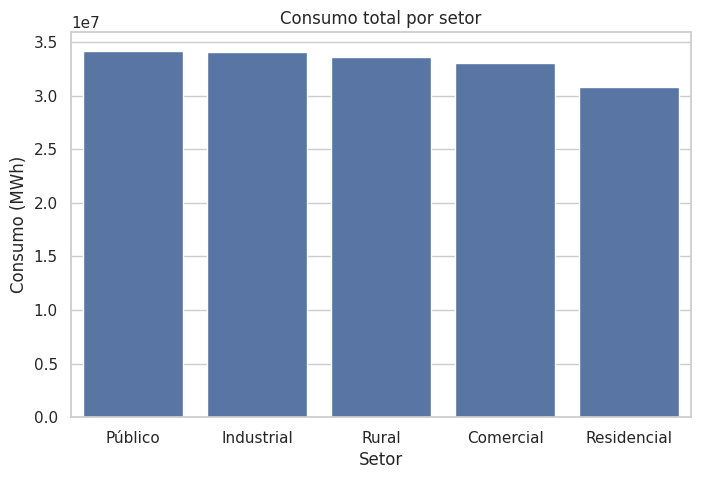

In [9]:
por_setor = df.groupby("setor_consumo")["consumo_mwh"].agg(total="sum", media="mean", registros="count").sort_values("total", ascending=False)
display(por_setor)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=por_setor.index, y=por_setor["total"], ax=ax)
ax.set_title("Consumo total por setor")
ax.set_xlabel("Setor")
ax.set_ylabel("Consumo (MWh)")
salvar("consumo_setor")

**Interpretação:** os cinco setores têm consumo total muito próximo. O Público lidera (≈ 34,2 milhões de MWh) e o Residencial é o menor (≈ 30,8 milhões), uma diferença de cerca de 10%. Não há um setor dominante nesta base.

### 7.2 Consumo por região: total versus média

,total,media,registros
regiao,,,
Sudeste,"59,834,504.66","38,355.45",1560
Nordeste,"35,098,644.90","36,561.09",960
Sul,"25,439,504.91","35,332.65",720
Norte,"22,911,841.60","38,186.40",600
Centro-Oeste,"22,413,586.50","37,355.98",600


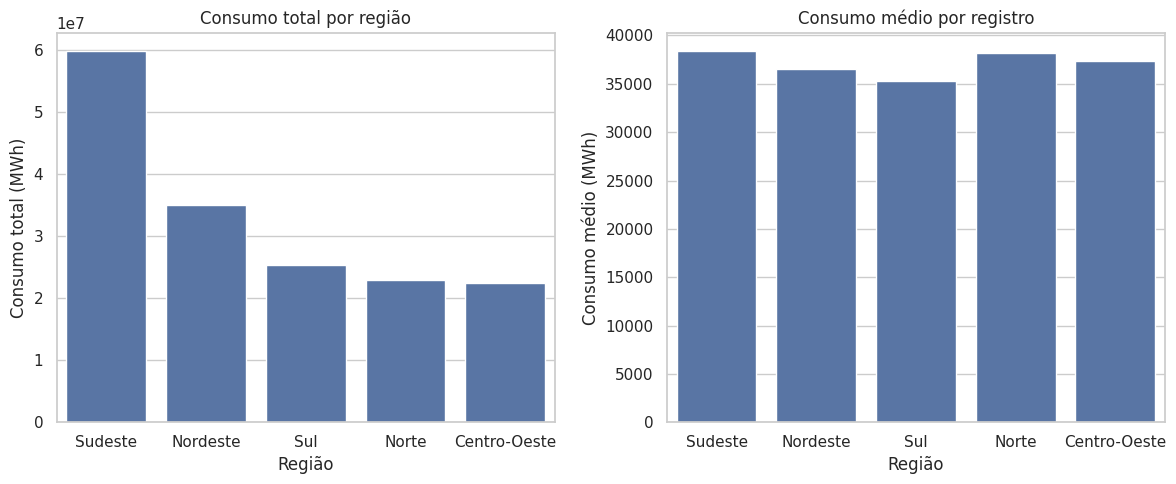

In [10]:
por_regiao = df.groupby("regiao")["consumo_mwh"].agg(total="sum", media="mean", registros="count").sort_values("total", ascending=False)
display(por_regiao)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=por_regiao.index, y=por_regiao["total"], ax=axes[0])
axes[0].set_title("Consumo total por região")
axes[0].set_xlabel("Região")
axes[0].set_ylabel("Consumo total (MWh)")
sns.barplot(x=por_regiao.index, y=por_regiao["media"], ax=axes[1], order=por_regiao.index)
axes[1].set_title("Consumo médio por registro")
axes[1].set_xlabel("Região")
axes[1].set_ylabel("Consumo médio (MWh)")
plt.tight_layout()
salvar("consumo_regiao")

**Interpretação:** o Sudeste concentra ≈ 36% do consumo total (59,8 milhões de MWh), seguido do Nordeste. Porém, o consumo **médio por registro** é praticamente igual entre as regiões (de ≈ 35,3 mil a 38,4 mil MWh). A liderança do Sudeste vem do maior número de registros (1.560 de 4.440), isto é, de mais estados e combinações, e não de um consumo individual superior.

### 7.3 Consumo por estado

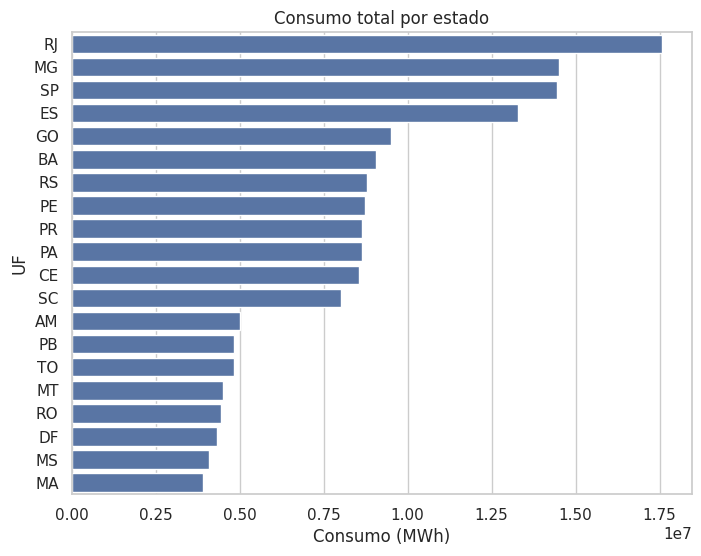

uf
RJ   17,580,197.52
MG   14,511,749.22
SP   14,452,348.40
ES   13,290,209.52
GO    9,497,124.68
Name: consumo_mwh, dtype: float64

In [11]:
por_uf = df.groupby("uf")["consumo_mwh"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=por_uf.values, y=por_uf.index, ax=ax)
ax.set_title("Consumo total por estado")
ax.set_xlabel("Consumo (MWh)")
ax.set_ylabel("UF")
salvar("consumo_uf")
por_uf.head(5)

**Interpretação:** RJ (≈ 17,6 milhões de MWh), MG e SP (≈ 14,5 milhões cada) lideram, todos no Sudeste, o que explica a posição da região.

### 7.4 Evolução temporal e média móvel

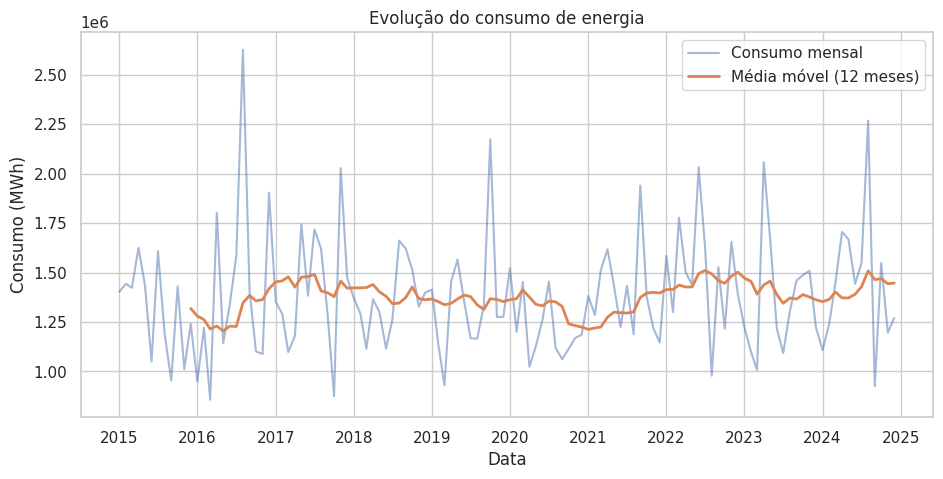

,total,variacao_%
ano,,
2015,"15,819,383.44",NaN
2016,"17,025,926.89",7.63
2017,"17,053,703.49",0.16
2018,"16,351,952.63",-4.11
2019,"16,242,200.62",-0.67
2020,"14,692,967.89",-9.54
2021,"16,763,939.07",14.09
2022,"18,027,501.70",7.54
2023,"16,350,579.12",-9.30


In [12]:
serie = df.groupby("data")["consumo_mwh"].sum()
media_movel = serie.rolling(12).mean()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(serie.index, serie.values, alpha=0.5, label="Consumo mensal")
ax.plot(media_movel.index, media_movel.values, linewidth=2, label="Média móvel (12 meses)")
ax.set_title("Evolução do consumo de energia")
ax.set_xlabel("Data")
ax.set_ylabel("Consumo (MWh)")
ax.legend()
salvar("serie_temporal")

anual = df.groupby("ano")["consumo_mwh"].sum().to_frame("total")
anual["variacao_%"] = anual["total"].pct_change() * 100
anual

**Interpretação:** a série mensal oscila bastante, mas a média móvel de 12 meses mostra um consumo estável em torno de 1,4 milhão de MWh por mês, sem tendência clara de crescimento. O destaque é **2020**, com queda de ≈ 9,5% frente a 2019 (de 16,2 para 14,7 milhões de MWh), seguida de recuperação em 2021 e do pico de **2022** (≈ 18,0 milhões).

### 7.5 Sazonalidade

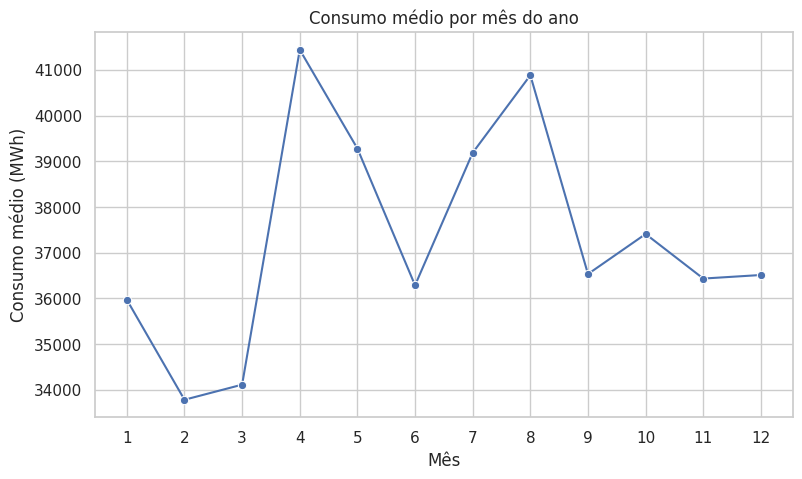

In [13]:
mensal = df.groupby("mes")["consumo_mwh"].mean()
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(x=mensal.index, y=mensal.values, marker="o", ax=ax)
ax.set_xticks(range(1, 13))
ax.set_title("Consumo médio por mês do ano")
ax.set_xlabel("Mês")
ax.set_ylabel("Consumo médio (MWh)")
salvar("sazonalidade")

**Interpretação:** o consumo médio é mais alto em **abril** (≈ 41,4 mil MWh) e **agosto** (≈ 40,9 mil), e mais baixo em **fevereiro** (≈ 33,8 mil). A variação entre meses chega a ≈ 23%, indicando sazonalidade moderada. Como a base é simulada, esse padrão deve ser lido com cautela.

### 7.6 Distribuição do consumo e nível de demanda

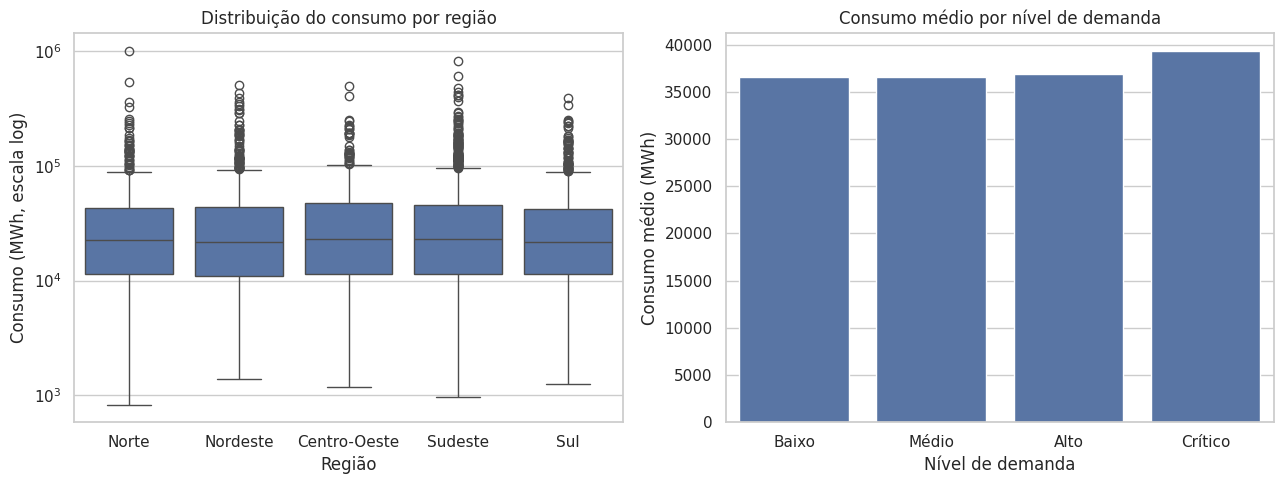

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="regiao", y="consumo_mwh", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Distribuição do consumo por região")
axes[0].set_xlabel("Região")
axes[0].set_ylabel("Consumo (MWh, escala log)")
media_nivel = df.groupby("nivel_demanda", observed=True)["consumo_mwh"].mean()
sns.barplot(x=media_nivel.index, y=media_nivel.values, ax=axes[1])
axes[1].set_title("Consumo médio por nível de demanda")
axes[1].set_xlabel("Nível de demanda")
axes[1].set_ylabel("Consumo médio (MWh)")
plt.tight_layout()
salvar("distribuicao_demanda")

**Interpretação:** as cinco regiões têm distribuições muito parecidas, com mediana semelhante e vários valores extremos (os outliers). O nível **Crítico** apresenta consumo médio um pouco maior (≈ 39,3 mil MWh) que os demais (≈ 36,6 a 36,9 mil), mas a diferença é pequena.

### 7.7 Correlação estatística

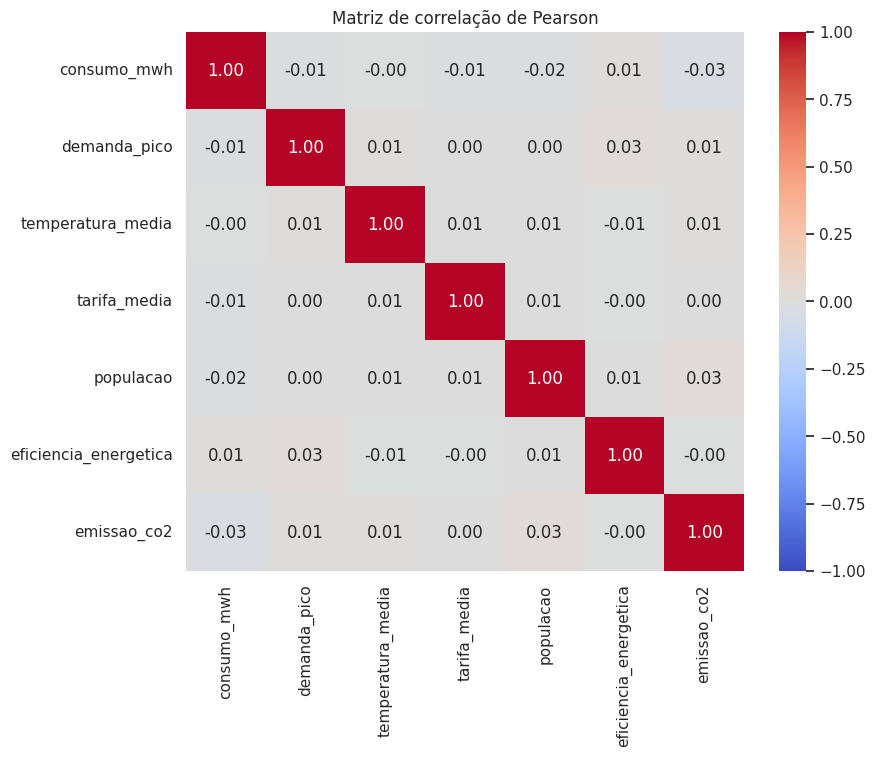

Correlações com o consumo (ordenadas):


emissao_co2             -0.03
populacao               -0.02
tarifa_media            -0.01
eficiencia_energetica    0.01
demanda_pico            -0.01
temperatura_media       -0.00
Name: consumo_mwh, dtype: float64

In [15]:
cols = ["consumo_mwh", "demanda_pico", "temperatura_media", "tarifa_media", "populacao", "eficiencia_energetica", "emissao_co2"]
corr = df[cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlação de Pearson")
salvar("correlacao")

print("Correlações com o consumo (ordenadas):")
corr["consumo_mwh"].drop("consumo_mwh").sort_values(key=abs, ascending=False)

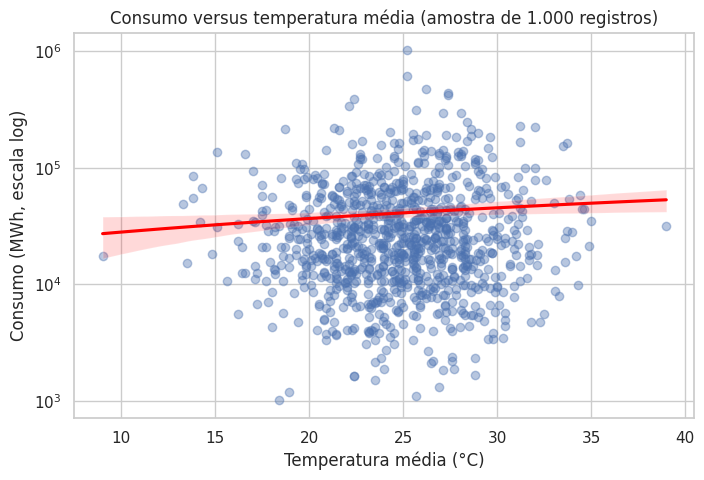

r de Pearson (consumo × temperatura): -0.002


In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
amostra = df.sample(1000, random_state=42)
sns.regplot(data=amostra, x="temperatura_media", y="consumo_mwh", scatter_kws={"alpha": 0.4}, line_kws={"color": "red"}, ax=ax)
ax.set_yscale("log")
ax.set_title("Consumo versus temperatura média (amostra de 1.000 registros)")
ax.set_xlabel("Temperatura média (°C)")
ax.set_ylabel("Consumo (MWh, escala log)")
salvar("consumo_temperatura")
print("r de Pearson (consumo × temperatura):", round(df["consumo_mwh"].corr(df["temperatura_media"]), 3))

**Interpretação:** todas as correlações com o consumo ficam próximas de zero (módulo menor que 0,05). Não há relação linear entre consumo e temperatura, tarifa, população, eficiência ou emissões, e a reta do gráfico de dispersão é praticamente horizontal. Isso é coerente com uma base simulada em que as variáveis foram geradas de forma independente. Na prática, o consumo real costuma responder a temperatura e população; aqui, essa relação não aparece.

### 7.8 Emissões e eficiência por setor

,emissao_media,eficiencia_media
setor_consumo,,
Comercial,"41,779.94",69.50
Público,"41,317.35",70.32
Rural,"40,470.59",69.94
Industrial,"39,724.72",69.62
Residencial,"39,214.74",69.58


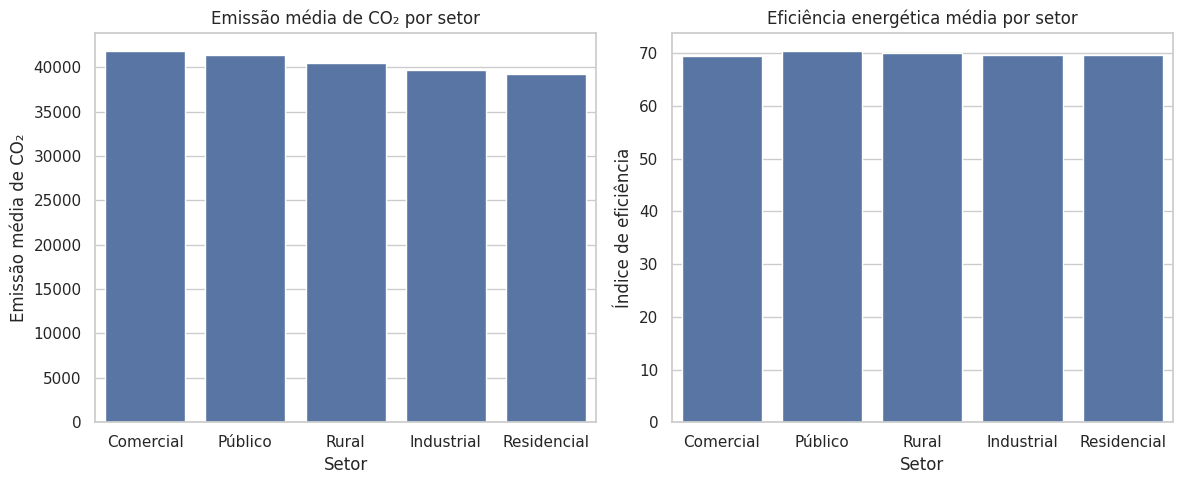

In [17]:
ef = df.groupby("setor_consumo").agg(emissao_media=("emissao_co2", "mean"), eficiencia_media=("eficiencia_energetica", "mean")).sort_values("emissao_media", ascending=False)
display(ef)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=ef.index, y=ef["emissao_media"], ax=axes[0])
axes[0].set_title("Emissão média de CO₂ por setor")
axes[0].set_xlabel("Setor")
axes[0].set_ylabel("Emissão média de CO₂")
sns.barplot(x=ef.index, y=ef["eficiencia_media"], ax=axes[1])
axes[1].set_title("Eficiência energética média por setor")
axes[1].set_xlabel("Setor")
axes[1].set_ylabel("Índice de eficiência")
plt.tight_layout()
salvar("emissao_eficiencia")

**Interpretação:** a emissão média é maior no Comercial e no Público (≈ 41,8 mil e 41,3 mil) e menor no Residencial (≈ 39,2 mil). A eficiência média gira em torno de 70 pontos em todos os setores, sem grandes diferenças.

## 8. Funcionalidade avançada: persistência em banco (SQLAlchemy + SQLite)

In [18]:
engine = create_engine(f"sqlite:///{(BANCO / 'energia.db').as_posix()}")
df.to_sql("consumo", engine, if_exists="replace", index=False)

consulta = text("""
    SELECT regiao, setor_consumo, ROUND(SUM(consumo_mwh), 0) AS total_mwh
    FROM consumo
    GROUP BY regiao, setor_consumo
    ORDER BY total_mwh DESC
    LIMIT 5
""")
pd.read_sql(consulta, engine)

,regiao,setor_consumo,total_mwh
0,Sudeste,Público,"12,745,886.00"
1,Sudeste,Rural,"12,106,603.00"
2,Sudeste,Comercial,"11,980,853.00"
3,Sudeste,Residencial,"11,526,282.00"
4,Sudeste,Industrial,"11,474,880.00"


Os dados tratados foram gravados na tabela `consumo` do arquivo `database/energia.db`, e o dashboard Streamlit lê esse banco. A consulta SQL acima mostra as cinco combinações região × setor de maior consumo.

## 9. Conclusão
**Principais achados**
- O consumo total é de ≈ **165,7 milhões de MWh**, distribuído de forma equilibrada entre os setores (diferença de ≈ 10% entre o maior e o menor).
- O **Sudeste** concentra ≈ 36% do consumo, devido ao maior número de registros; o consumo médio por registro é semelhante entre regiões.
- A série temporal é estável, com **queda em 2020 (≈ −9,5%)**, recuperação em 2021 e pico em 2022. Há sazonalidade moderada, com abril e agosto no topo e fevereiro no piso.
- Não há **correlação linear relevante** entre o consumo e as demais variáveis.

**Limitações:** a base é simulada, o que explica a ausência de correlações e a homogeneidade entre grupos; a tarifa foi assumida em R$/kWh para o custo estimado.

**Recomendações:** validar a metodologia com dados reais (por exemplo, da EPE ou da ANEEL) e, com dados reais, testar modelos que relacionem consumo, temperatura e população.

**Funcionalidades avançadas implementadas:** persistência em banco (SQLAlchemy + SQLite), correlação estatística e séries temporais avançadas (média móvel e variação anual).